# Exploratory Data Analysis: Frequency Decomposition of ERA5 Zonal Wind

This notebook performs spectral analysis of ERA5 zonal wind data at 850 hPa to decompose atmospheric variability into different frequency bands using Fast Fourier Transform (FFT).

## Import Libraries and Custom Modules

Load necessary Python libraries for data analysis, visualization, and custom modules for cartographic grid plotting and spectral analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import metpy as mp
import sys
from pathlib import Path
import cartopy.crs as ccrs
import tqdm
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.2)

if True:
    # Add custom module paths
    pr11_base = Path('/home11/grad/2025/jm582228/pr11')
    for folder in ['cartogrid', 'utilities', 'geophysical-signal-tools']:
        sys.path.insert(0, str(pr11_base / folder))

    path = '/nfs/home11/grad/2025/jm582228/pr11/research/code/data_adquisition/era5/'
    sys.path.insert(0, str(path))

    import cartogrid as cg
    import utilities as util
    import spectral_analysis as spa
    import era5_parameters as era5

print("✓ Modules imported successfully")

✓ Modules imported successfully


## Load ERA5 Zonal Wind Data

Load daily mean zonal wind (u-wind) data at 850 hPa from ERA5 reanalysis using xarray's multi-file dataset capability.

In [2]:
folder_root = '/nfs/home11/grad/2025/jm582228/Data_Free2/era5/pressure_levels/'

level_data = 850  # hPa level for zonal wind
var = 'uwnd'
short_name = era5.pressure_variables[var]['shortName']

folder_data = folder_root + f'{var}/{level_data}hPa/daily/'


pattern = f'era5_{var}_daymean_remapbil_{level_data}hPa_*.nc'

# Load data with xarray
data = xr.open_mfdataset(
    folder_data + pattern,
    # combine='by_coords',
    chunks={'time': 'auto', 'latitude': -1,
            'longitude': -1}  # chunk only time
)[short_name].sel(pressure_level=level_data)

In [3]:
# Convert to numpy array
data_array = data.compute().values 

In [4]:
serie = data_array[:, 0, 0]  # Extract the time series at the first grid point

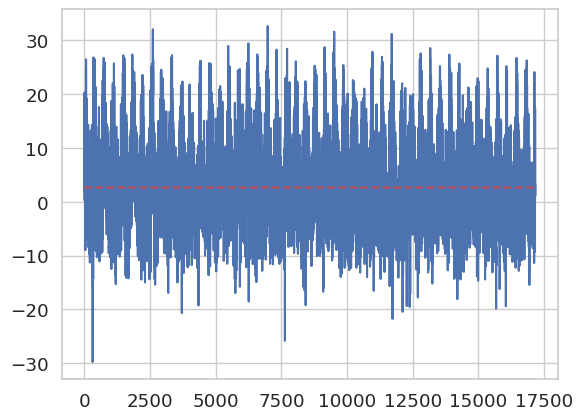

In [10]:
plt.plot(serie)
plt.plot(np.zeros_like(serie)+serie.mean(), 'r--')

In [11]:
# Compute FFT frequencies and convert to periods

detrended_series = serie - np.mean(serie)  # Detrend by removing the mean
sampling_interval = 1  # Assuming daily data, so 1 day between samples

freqs = np.fft.fftfreq(len(detrended_series), sampling_interval)
# Handle division by zero (set zero frequency to infinity)
periods = np.where(freqs != 0, 1 / np.abs(freqs), np.inf)

# Compute Fourier coefficients and power spectrum
fourier_coeffs = np.fft.fft(detrended_series)
amplitud = np.abs(fourier_coeffs)
power = (amplitud ** 2)

# Normalize power spectrum by total power and scale by series variance
normalized_power = (power/np.sum(power)) * np.var(detrended_series)
# Total explained variance of the detrended series
exp_var = (normalized_power / np.var(detrended_series)) * 100.


/tmp/ipykernel_1439783/1832022997.py:8: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs != 0, 1 / np.abs(freqs), np.inf)


In [13]:
serie.shape

(17167,)

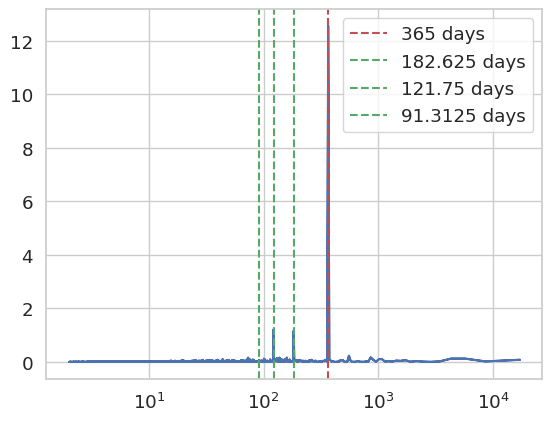

In [22]:
plt.plot(periods,  exp_var)
plt.xscale('log')
plt.axvline(365.25, color='r', linestyle='--', label='365 days')
plt.axvline(365.25/2, color='g', linestyle='--', label=f'{365.25/2} days')
plt.axvline(365.25/3, color='g', linestyle='--', label=f'{365.25/3} days')
plt.axvline(365.25/4, color='g', linestyle='--', label=f'{365.25/4} days')
plt.legend()

In [23]:
fourier_coeffs

array([-3.0090809e-03-3.1263880e-13j, -7.8911737e+02-3.7413604e+03j,
        8.9607928e+02-1.5844298e+03j, ..., -2.2444708e+02+4.7324243e+03j,
        8.9607928e+02+1.5844298e+03j, -7.8911737e+02+3.7413604e+03j],
      dtype=complex64)

In [25]:
# mask to extract different bands
ac_period = (364, 366)  # days
mask_AC = np.where((np.abs(periods) >= ac_period[0]) &
                    (periods <= ac_period[1]))

# Compute explained variances for each band
exp_var_AC = np.nansum(exp_var[mask_AC])

In [26]:
exp_var_AC

np.float32(25.119013)

## FFT-Based Frequency Decomposition

Perform Fast Fourier Transform (FFT) on each grid point's time series to decompose variability into frequency bands:

**Frequency Bands:**
- **Annual Cycle (AC)**: 364-366 days
- **Intra-Seasonal (IS)**: 20-90 days (includes MJO timescales)
- **Inter-Annual (IA)**: 2-7 years (ENSO and longer-term variability)
- **Background (BG)**: >100 days (low-frequency variability)
- **Subseasonal (SS)**: <80 days (high-frequency variability)

**Method:**
1. For each grid point, extract time series and detrend by removing the mean
2. Apply FFT to compute frequency spectrum and convert to period domain
3. Calculate normalized power spectrum scaled by variance
4. Apply frequency masks to isolate different bands
5. Compute variance and explained variance (%) for each band

In [4]:
# Get the shape of the data array
dtime, dlat, dlon = data_array.shape

# Reshape data to 2D array: (time, space) for easier processing
data_reshaped = data_array.reshape(dtime, dlat * dlon)

# Variance for different frequency bands
var_AC = np.zeros(dlat * dlon) * np.nan  # Annual Cycle
var_IS = np.zeros(dlat * dlon) * np.nan  # Intra-Seasonal Cycle
var_IA = np.zeros(dlat * dlon) * np.nan  # Inter-Annual Cycle
var_BG = np.zeros(dlat * dlon) * np.nan  # Background (longer than 100 days)
var_SS = np.zeros(dlat * dlon) * np.nan  # Subseasonal (shorter than 80 days)


# Explained variance for different frequency bands
exp_var_AC = np.zeros(dlat * dlon) * np.nan  # Annual Cycle
exp_var_IS = np.zeros(dlat * dlon) * np.nan  # Intra-Seasonal
exp_var_IA = np.zeros(dlat * dlon) * np.nan  # Inter-Annual Cycle

# Background (longer than 100 days)
exp_var_BG = np.zeros(dlat * dlon) * np.nan
# Subseasonal (shorter than 80 days)
exp_var_SS = np.zeros(dlat * dlon) * np.nan

# Annual, Intra-Seasonal, Inter-annual periods in days
ac_period = (364, 366)  # days
is_period = (20, 90)  # days
ia_period = (2*365.25, 7*365.25)  # days

# Background and Subseasonal cutoff periods
bg_cutoff = 100  # days
ss_cutoff = 80  # days

for i in tqdm.tqdm(range(dlat * dlon), desc='Gridpoints'):
    # Extract time series for current gridpoint
    series = data_reshaped[:, i]

    # Define sampling interval (daily data)
    sampling_interval = 1

    # Calculate mean and detrend the series
    mean_value = np.mean(series)
    detrended_series = series - mean_value

    # Compute FFT frequencies and convert to periods
    freqs = np.fft.fftfreq(len(detrended_series), sampling_interval)
    # Handle division by zero (set zero frequency to infinity)
    periods = np.where(freqs != 0, 1 / np.abs(freqs), np.inf)

    # Compute Fourier coefficients and power spectrum
    fourier_coeffs = np.fft.fft(detrended_series)
    amplitud = np.abs(fourier_coeffs)
    power = (amplitud ** 2)

    # Normalize power spectrum by total power and scale by series variance
    normalized_power = (power/np.sum(power)) * np.var(detrended_series)
    # Total explained variance of the detrended series
    exp_var = (normalized_power / np.var(detrended_series)) * 100.

    # mask to extract different bands
    mask_AC = np.where((np.abs(periods) >= ac_period[0]) &
                       (periods <= ac_period[1]))
    mask_IS = np.where((np.abs(periods) >= is_period[0]) &
                       (periods <= is_period[1]))
    mask_IA = np.where((np.abs(periods) >= ia_period[0]) &
                       (periods <= ia_period[1]))

    mask_BG = np.where(np.abs(periods) >= bg_cutoff)
    mask_SS = np.where(np.abs(periods) <= ss_cutoff)

    # Compute variances for each band
    var_AC[i] = np.nansum(normalized_power[mask_AC])
    var_IS[i] = np.nansum(normalized_power[mask_IS])
    var_IA[i] = np.nansum(normalized_power[mask_IA])
    var_BG[i] = np.nansum(normalized_power[mask_BG])
    var_SS[i] = np.nansum(normalized_power[mask_SS])

    # Compute explained variances for each band
    exp_var_AC[i] = np.nansum(exp_var[mask_AC])
    exp_var_IS[i] = np.nansum(exp_var[mask_IS])
    exp_var_IA[i] = np.nansum(exp_var[mask_IA])
    exp_var_BG[i] = np.nansum(exp_var[mask_BG])
    exp_var_SS[i] = np.nansum(exp_var[mask_SS])


Gridpoints:   0%|          | 0/21960 [00:00<?, ?it/s]/tmp/ipykernel_1730662/1676703708.py:48: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs != 0, 1 / np.abs(freqs), np.inf)
Gridpoints: 100%|██████████| 21960/21960 [00:54<00:00, 405.77it/s]


## Reshape Variance Results and Calculate Standard Deviations

This cell transforms the 1D variance arrays back into 2D spatial grids and computes standard deviations from the variance values.

**Reshaping from 1D to 2D:**
- All variance and explained variance arrays are reshaped from `(dlat * dlon,)` to `(dlat, dlon)` for spatial plotting

**Computing Standard Deviations:**
- `total_std`: Overall standard deviation of the raw data across time dimension
- `std_AC`, `std_IS`, `std_IA`, `std_BG`, `std_SS`: Square root of variance for each frequency band (Annual Cycle, Intra-Seasonal, Inter-Annual, Background, Subseasonal)

In [5]:
# Reshape results back to (latitude, longitude)
var_AC = var_AC.reshape(dlat, dlon)
var_IS = var_IS.reshape(dlat, dlon)
var_IA = var_IA.reshape(dlat, dlon)
var_BG = var_BG.reshape(dlat, dlon)
var_SS = var_SS.reshape(dlat, dlon)

exp_var_AC = exp_var_AC.reshape(dlat, dlon)
exp_var_IS = exp_var_IS.reshape(dlat, dlon)
exp_var_IA = exp_var_IA.reshape(dlat, dlon)
exp_var_BG = exp_var_BG.reshape(dlat, dlon)
exp_var_SS = exp_var_SS.reshape(dlat, dlon)

# %%
# Compute standard deviations
total_std = np.std(data_array, axis=0)
std_AC = np.sqrt(var_AC)
std_IS = np.sqrt(var_IS)
std_IA = np.sqrt(var_IA)
std_BG = np.sqrt(var_BG)
std_SS = np.sqrt(var_SS)


## Create Spatial Visualization

Generate a multi-panel figure showing:
1. Total standard deviation of zonal wind
2. Explained variance (%) for different frequency bands

This visualization helps identify spatial patterns of variability at different timescales across the tropical region.

### Additional Resources
- **CartoGrid documentation:** https://github.com/jdmantillaq/cartogrid

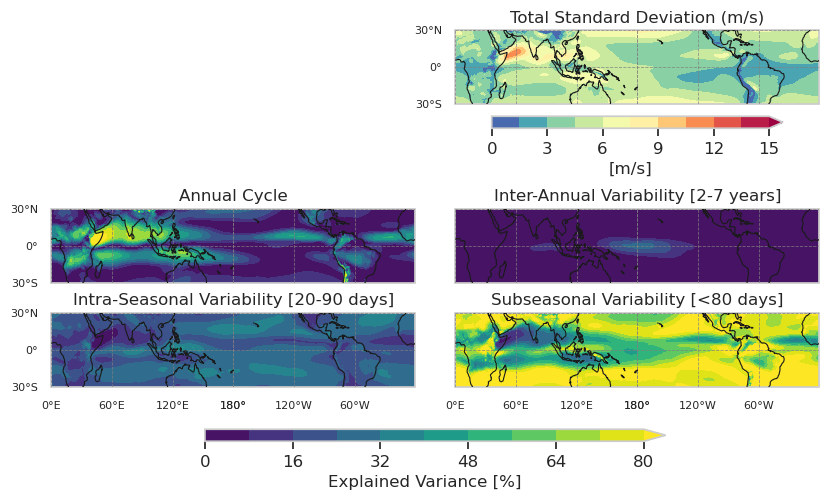

In [6]:
# Create DataArrays for easy plotting and saving
proj = ccrs.PlateCarree(central_longitude=180)
num_rows = 3
num_columns = 2

img_extent = (-180, 180, -30, 30)

# Use the function to calculate properties of the grid
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(
    num_rows, num_columns, horiz_spacing=0.05, vert_spacing=0.1)


y_coords[0] += 0.25  # Adjust y-coordinates upwards for titles

# Create a figure with a specified size
fig = plt.figure(figsize=(8, 3))


level_std = np.linspace(0, 15, 11)
cmap_std = sns.color_palette("Spectral_r", as_cmap=True)

level_expvar = np.linspace(0, 80, 11)
cmap_expvar = sns.color_palette("viridis", as_cmap=True)

matrix_data = [
    total_std,
    exp_var_AC, exp_var_IA,
    exp_var_IS, exp_var_SS
]

title_list = [
    'Total Standard Deviation (m/s)',
    'Annual Cycle',
    'Inter-Annual Variability [2-7 years]',
    'Intra-Seasonal Variability [20-90 days]',
    'Subseasonal Variability [<80 days]']

# Initialize the index for selecting time slices of the temperature data
idx = 0


# Loop through each row and column to create a grid of subplots
for ri in range(num_rows):
    for ci in range(num_columns):

        if ri == 0 and ci == 0:
            # Skipping the last subplot of the first row(empty)
            continue

        # Add axes to the figure with the calculated properties
        ax = fig.add_axes([x_coords[ci], y_coords[ri],
                           x_fig, y_fig],
                          projection=proj)
        # Add geographic features to the plot

        # map resolution is set to 10m, [10, 50 and 110] are available
        ax = cg.add_map_features(ax, lon_step=60, lat_step=30,
                                 map_resolution=110, fontsize_latlon=8)

        # Set aspect ratio of the plot
        ax.set_aspect('auto')

        # Set the image extent and aspect ratio of the plot
        ax.set_extent(img_extent, proj)

        ax.set_title(title_list[idx], fontsize=12)

        # Remove y-axis labels for subplots that aren't in the first column
        if ci > 0 and ri > 0:
            ax.set_yticklabels([])

        # Remove x-axis labels for subplots that are not in the last row
        if ri < (num_rows - 1):
            ax.set_xticklabels([])

        # Plot the temperature data for the current time slice

        var_values = matrix_data[idx]

        levels = level_std if idx == 0 else level_expvar
        cmap = cmap_std if idx == 0 else cmap_expvar

        if idx == 0:
            # Standard Deviation plot
            cs_0 = ax.contourf(data.longitude.values,
                               data.latitude.values,
                               var_values,
                               levels,
                               cmap=cmap, extend='max',
                               transform=ccrs.PlateCarree())
        else:
            # Explained Variance plots
            cs = ax.contourf(data.longitude.values,
                             data.latitude.values,
                             var_values,
                             levels,
                             cmap=cmap, extend='max',
                             transform=ccrs.PlateCarree())

        idx += 1


label = '[m/s]'
cg.add_colorbar_col(fig, cs_0, label,
                    grid_prop=grid_prop,
                    col_idx=1,
                    cbar_factor=0.8,
                    cbar_width=0.04,
                    y_coord_cbar=y_coords[0] - 0.08)
        

# Define the orientation and label of the colorbar
orientation = 'horizontal'
label = 'Explained Variance [%]'

# Add a horizontal colorbar to the figure
cg.add_colorbar(fig=fig, cs=cs, label=label,
                orientation=orientation,
                grid_prop=grid_prop,
                cbar_factor=0.6,
                cbar_width=0.04,
                y_coord_cbar=-0.15)